🎯 **You Sank My Function** — Black-Box Optimisation Capstone · Imperial College Business School

**Pipeline (B)** · [04 Consolidate](../pipeline/04_consolidate_data.ipynb) → [06 Diagnose](../pipeline/06_diagnose.ipynb) → [05 Suggest engine](../pipeline/05_suggest_engine.ipynb) · [07 Run week + report](../pipeline/07_run_week_and_report.ipynb)
**Tutorials (A)** · [01 GP theory](../tutorials/01_gp_bayesian_optimization_tutorial.ipynb) · [02 Acquisition engine](../tutorials/02_gp_suggest_input_tutorial.ipynb) · [03 EDA & prototype](../tutorials/03_capstone_eda_and_prototype.ipynb)
**Diagnostics (C)** · [A1 SVM](../diagnostics/A1_svm_analysis.ipynb) · [A2 Logistic regression](../diagnostics/A2_logistic_regression.ipynb) · [A3 Landscape gallery](../diagnostics/A3_landscape_gallery.ipynb)
**Neural + LLM (D)** · [08 NN (educational)](../neural/08_neural_surrogates_edu.ipynb) · [09 NN for F6](../neural/09_neural_surrogates_F6.ipynb) · [10 NN engine](../neural/10_neural_surrogates_engine.ipynb)

> 📍 **This notebook** — **Tutorial 2 (A · educational, not in the weekly loop). GP theory turned into a working query engine (UCB / PI / variance).**

---

# 🎯 Part 2 — Suggesting New Inputs for the 8 Black-Box Functions

**Capstone Black Box Challenge**  
**Strategy:** Pure GP-based Bayesian Optimisation (UCB / Variance / PI) — no benchmarks, fully black-box.

---

## Challenge Rules (what matters for this notebook)

| Rule | Detail |
|------|--------|
| **Submission format** | `x1-x2-x3-...-xn` where each `xᵢ` starts with `0`, 6 decimal places |
| **Example (2D)** | `0.123456-0.654321` |
| **Submission method** | Paste into the capstone portal (one query at a time) |
| **Budget** | Grows by 1 per module: 10 points in Module 12 → 22 points in Module 24 |
| **Goal** | Maximise f(x) for all 8 functions |
| **Input domain** | All inputs in `[0, 1]` (values always start with `0.`) |

**This notebook's job:** use the GP surrogate to suggest the best next query,  
then format it as a ready-to-paste portal string.

---

| Function | Dim | Initial points | Description |
|----------|-----|---------------|-------------|
| 1 | 2D | 10 | Contamination sources in 2D area |
| 2 | 2D | 10 | Noisy ML model, many local optima |
| 3 | 3D | 15 | Drug discovery (side effects → negated) |
| 4 | 4D | 30 | Warehouse/ML hyperparameter tuning |
| 5 | 4D | 20 | Chemical yield (likely unimodal) |
| 6 | 5D | 20 | Cake recipe (combined negative score) |
| 7 | 6D | 30 | ML hyperparameter optimisation |
| 8 | 8D | 40 | 8-hyperparameter deep learning model |

---

## Step 0 — Imports and Configuration

In [1]:
import os
"""
STEP 0 — Imports and global configuration.

Two paths to configure:
  ROOT_DIR  → where your initial_data folder lives
  LOG_FILE  → CSV log of every query you submit (important for tracking)
"""

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
import csv
from datetime import datetime

# ── CONFIGURE THESE PATHS ───────────────────────────────────────────────
ROOT_DIR = Path(os.environ.get("BBO_INITIAL_DATA", "data/initial_data"))
LOG_FILE = Path("query_log.csv")   # keeps record of all submissions
# ───────────────────────────────────────────────────────────────────────

# ── GLOBAL GP HYPERPARAMETERS ───────────────────────────────────────────
# These are defaults. Each function section below may override them.
# See Part 1 of this series for the theory behind each parameter.

NOISE_LEVEL      = 1e-10   # α: near-zero = trust observations exactly
BETA             = 1.96    # UCB β: 95% upper confidence bound
ETA              = 0.01    # PI η: require ≥1% improvement above current best
CANDIDATES_PER_DIM = 500   # random candidates per dimension for acquisition search

print("✓ Setup complete")
print(f"  Data directory : {ROOT_DIR}")
print(f"  Query log file : {LOG_FILE}")

✓ Setup complete
  Data directory : .\initial_data
  Query log file : .\query_log.csv


## Step 1 — Load All Initial Data

In [2]:
"""
STEP 1 — Load initial_inputs.npy and initial_outputs.npy for all 8 functions.

data['function_1']['input']  → np.ndarray shape (10, 2)  ← X matrix (initial observations)
data['function_1']['output'] → np.ndarray shape (10,)    ← y vector (initial outputs)

THEORY CONNECTION:
  These arrays are the GP's training data (X_obs, y_obs from Part 1).
  We fit the GP on these, then ask: 'where should I query next?'
"""

def load_all_data(root_dir: Path) -> dict:
    data = {}
    subdirs = sorted(
        [p for p in root_dir.iterdir() if p.is_dir() and p.name.startswith("function_")],
        key=lambda p: int(p.name.split("_")[1])
    )
    for subdir in subdirs:
        entry = {}
        for label, fname in [("input", "initial_inputs.npy"), ("output", "initial_outputs.npy")]:
            path = subdir / fname
            if path.exists():
                entry[label] = np.load(path, allow_pickle=True)
        if entry:
            data[subdir.name] = entry
    return data


data = load_all_data(ROOT_DIR)

print(f"Loaded {len(data)} functions\n")
print(f"  {'Function':<14} {'Input shape':<16} {'Dim':<6} {'N pts':<7} {'Best y so far'}")
print(f"  {'-'*60}")
for fname, arrays in data.items():
    X = arrays['input']
    y = arrays['output']
    print(f"  {fname:<14} {str(X.shape):<16} {X.shape[1]:<6} {X.shape[0]:<7} {max(y):.6f}")

Loaded 8 functions

  Function       Input shape      Dim    N pts   Best y so far
  ------------------------------------------------------------
  function_1     (10, 2)          2      10      0.000000
  function_2     (10, 2)          2      10      0.611205
  function_3     (15, 3)          3      15      -0.034835
  function_4     (30, 4)          4      30      -4.025542
  function_5     (20, 4)          4      20      1088.859618
  function_6     (20, 5)          5      20      -0.714265
  function_7     (30, 6)          6      30      1.364968
  function_8     (40, 8)          8      40      9.598482


## Step 2 — The Core Engine: GP Surrogate + Acquisition

### Theory recap (from Part 1)

Given initial data $(X, y)$, the GP posterior at any candidate $x$ gives:
- $\mu^*(x)$ = our best guess of $f(x)$ → **exploitation signal**
- $\sigma^*(x)$ = our uncertainty about $f(x)$ → **exploration signal**

Three acquisition functions use these differently:

| | Formula | Behaviour |
|--|---------|----------|
| **UCB** | $\mu + \beta\sigma$ | Optimistic: "this might be great" |
| **Variance** | $\sigma^2$ | Curious: "I don't know what's here" |
| **PI** | $\Phi\!\left(\frac{\mu - y^*_{\max} - \eta}{\sigma}\right)$ | Prudent: "what's the probability of improvement?" |

In [3]:
"""
STEP 2 — The acquisition engine.

suggest_next_query() takes existing observations and returns:
  1. The best next input as a numpy array  → for further computation
  2. A portal-ready string                → copy-paste into the submission portal

PORTAL FORMAT RULE:
  Each dimension is formatted to 6 decimal places, separated by '-'
  Values must start with '0' (guaranteed because domain is [0,1])
  Example: 0.123456-0.654321  for a 2D query

THEORY → CODE map:
  gp.fit(X, y)                         ← computes posterior (matrix inversion)
  mu, sigma = gp.predict(X_cand, ...)  ← μ*(x), σ*(x) at candidates
  UCB:  mu + beta * sigma              ← exploitation + exploration
  Var:  sigma ** 2                     ← exploration only
  PI:   norm.cdf(z)                    ← probability of beating current best
"""

def format_portal_string(x: np.ndarray) -> str:
    """
    Convert a numpy array to the portal submission format.

    Rule: 'x1-x2-...-xn' where each xi has 6 decimal places
          and values are in [0,1] (so they all begin with '0')

    Example:
      np.array([0.123456, 0.654321]) → '0.123456-0.654321'
    """
    # np.clip ensures values stay in [0,1] — safety guard
    x_clipped = np.clip(x, 0.0, 1.0)
    # Format each dimension to exactly 6 decimal places
    parts = [f"{xi:.6f}" for xi in x_clipped]
    return "-".join(parts)


def suggest_next_query(
    X_obs: np.ndarray,
    y_obs: np.ndarray,
    acquisition:       str   = 'UCB',
    length_scale:      float = 0.2,
    noise_level:       float = NOISE_LEVEL,
    beta:              float = BETA,
    eta:               float = ETA,
    candidates_per_dim: int  = CANDIDATES_PER_DIM,
    random_state:      int   = 42,
    n_suggestions:     int   = 1,
) -> tuple:
    """
    Suggest the next input(s) to query.

    Parameters
    ----------
    X_obs : (n, d)   observed inputs
    y_obs : (n,)     observed outputs
    acquisition      'UCB', 'Variance', or 'PI'
    length_scale     RBF kernel ℓ  (how smooth the GP believes f is)
    noise_level      α = σ² observation noise (1e-10 = noiseless)
    beta             UCB exploration parameter
    eta              PI improvement threshold
    n_suggestions    how many candidates to return (portal takes 1 at a time)

    Returns
    -------
    suggestions : list of (np.ndarray, str) pairs
        Each element is (x_array, portal_string)
        x_array       → shape (d,)  raw numpy array
        portal_string → '0.xxxxxx-0.xxxxxx-...'  ready to paste
    gp_info : dict with 'mu', 'sigma', 'acq', 'X_cand' for diagnostics
    """
    rng   = np.random.default_rng(random_state)
    d     = X_obs.shape[1]
    n_cand = candidates_per_dim * d

    # ── A: Fit the GP surrogate ───────────────────────────────────────────
    # k(x,x') = exp(-||x-x'||² / 2ℓ²)   (RBF kernel)
    # fixed bounds = we set ℓ deliberately, not learned from data
    kernel = RBF(length_scale=length_scale, length_scale_bounds='fixed')

    # alpha = noise on the diagonal of k(X,X)  → small = trust observations
    gp = GaussianProcessRegressor(kernel=kernel, alpha=noise_level)
    gp.fit(X_obs, y_obs)   # ← computes posterior: [k(X,X) + σ²I]^{-1} y

    # ── B: Sample random candidate points in [0,1]^d ─────────────────────
    # We can't enumerate a grid in high dimensions (10^d points),
    # so we sample randomly and pick the best among them.
    X_cand = rng.uniform(0.0, 1.0, size=(n_cand, d))

    # ── C: Compute posterior at candidates ───────────────────────────────
    # mu   = μ*(X_cand)  — posterior mean  (what we expect at each candidate)
    # sigma = σ*(X_cand) — posterior std   (our uncertainty at each candidate)
    # NOTE: return_std=True gives σ (not σ²).
    mu, sigma = gp.predict(X_cand, return_std=True)

    # ── D: Compute acquisition values ────────────────────────────────────
    if acquisition == 'UCB':
        # UCB(x) = μ(x) + β·σ(x)
        # β=1.96 → 97.5th percentile of N(μ, σ²) → 95% upper confidence bound
        # Larger β = more exploration (go to uncertain regions)
        # Smaller β = more exploitation (go to high-mean regions)
        acq = mu + beta * sigma

    elif acquisition == 'Variance':
        # Variance(x) = σ²(x)
        # Completely ignores the mean — goes to the most uncertain region
        # Useful in very high dimensions where the mean is unreliable
        acq = sigma ** 2

    elif acquisition == 'PI':
        # PI(x) = Φ( (μ(x) - y*_max - η) / σ(x) )
        # z = how many standard deviations above (current_best + η) is our mean?
        # Φ = norm.cdf = P(standard normal ≤ z)
        # 1e-12: avoids division by zero at observed points where σ ≈ 0
        y_max = float(np.max(y_obs))
        z     = (mu - y_max - eta) / (sigma + 1e-12)
        acq   = norm.cdf(z)

    else:
        raise ValueError(f"Unknown acquisition '{acquisition}'. Use 'UCB', 'Variance', or 'PI'.")

    # ── E: Select top-N candidates ────────────────────────────────────────
    # argsort descending → best first
    sorted_idx  = np.argsort(acq)[::-1]
    top_idx     = sorted_idx[:n_suggestions]

    suggestions = []
    for idx in top_idx:
        x_arr    = X_cand[idx]              # raw numpy array, shape (d,)
        portal_s = format_portal_string(x_arr)  # '0.xxxxxx-0.xxxxxx-...'
        suggestions.append((x_arr, portal_s))

    gp_info = {'mu': mu, 'sigma': sigma, 'acq': acq, 'X_cand': X_cand, 'gp': gp}
    return suggestions, gp_info


# ── Quick format test ────────────────────────────────────────────────────
test_2d = np.array([0.123456789, 0.654321987])
test_3d = np.array([0.1, 0.5, 0.9])
print("Portal format tests:")
print(f"  2D: {format_portal_string(test_2d)}   ← expected: 0.123457-0.654322")
print(f"  3D: {format_portal_string(test_3d)}   ← expected: 0.100000-0.500000-0.900000")
print("\n✓ Engine ready")

Portal format tests:
  2D: 0.123457-0.654322   ← expected: 0.123457-0.654322
  3D: 0.100000-0.500000-0.900000   ← expected: 0.100000-0.500000-0.900000

✓ Engine ready


## Step 3 — Query Log

The portal gives you one query at a time. Keeping a log is essential:  
it records every suggestion alongside the response you get back, so the GP can use it next time.

In [4]:
"""
STEP 3 — Query log management.

The portal workflow is:
  1. Run suggest_next_query() → get a portal string
  2. Paste into the portal → get back a y value
  3. Call log_query() to record x and y
  4. Next time: load_log() to get all past observations → feed to suggest_next_query()

This creates a feedback loop that improves each suggestion.
"""

def log_query(function_name: str, x_array: np.ndarray, y_value: float,
              acquisition_used: str, log_file: Path = LOG_FILE):
    """
    Append a query and its result to the CSV log.

    Columns: timestamp, function, x_portal_string, y_value, acquisition
    """
    portal_string = format_portal_string(x_array)
    row = [
        datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        function_name,
        portal_string,
        f"{y_value:.8f}",
        acquisition_used
    ]
    # 'a' mode = append (create file if it doesn't exist)
    with open(log_file, 'a', newline='') as f:
        writer = csv.writer(f)
        # Write header if file is new/empty
        if log_file.stat().st_size == 0 if log_file.exists() else True:
            writer.writerow(['timestamp', 'function', 'x_portal', 'y_value', 'acquisition'])
        writer.writerow(row)
    print(f"  ✓ Logged: {function_name}  x={portal_string}  y={y_value:.6f}")


def load_log(function_name: str, log_file: Path = LOG_FILE) -> tuple:
    """
    Load all past queries for a function from the log.

    Returns
    -------
    X_log : np.ndarray shape (n_queries, d)  — queried inputs
    y_log : np.ndarray shape (n_queries,)    — received outputs
    """
    if not log_file.exists():
        return np.empty((0,)), np.empty((0,))

    rows_X, rows_y = [], []
    with open(log_file, 'r') as f:
        reader = csv.DictReader(f)
        for row in reader:
            if row['function'] == function_name:
                # Parse portal string '0.123456-0.654321' back to array
                x = np.array([float(v) for v in row['x_portal'].split('-')])
                y = float(row['y_value'])
                rows_X.append(x)
                rows_y.append(y)

    if len(rows_X) == 0:
        return np.empty((0,)), np.empty((0,))

    return np.array(rows_X), np.array(rows_y)


def merge_with_initial(function_name: str) -> tuple:
    """
    Combine initial data (from .npy) with all logged queries.

    This is the full X_obs, y_obs you feed to the GP.
    The GP improves with every new query you submit.
    """
    X_init = data[function_name]['input']
    y_init = data[function_name]['output']

    X_log, y_log = load_log(function_name)

    if len(X_log) == 0:
        return X_init, y_init

    X_all = np.vstack([X_init, X_log])
    y_all = np.concatenate([y_init, y_log])
    return X_all, y_all


print("✓ Query log functions defined")
print("""
Workflow per query:
  1. X_obs, y_obs = merge_with_initial('function_1')
  2. suggestions, info = suggest_next_query(X_obs, y_obs, ...)
  3. Copy portal string to submission portal
  4. Receive y value back from portal
  5. log_query('function_1', suggestions[0][0], y_received, 'UCB')
  6. Repeat from step 1
""")

✓ Query log functions defined

Workflow per query:
  1. X_obs, y_obs = merge_with_initial('function_1')
  2. suggestions, info = suggest_next_query(X_obs, y_obs, ...)
  3. Copy portal string to submission portal
  4. Receive y value back from portal
  5. log_query('function_1', suggestions[0][0], y_received, 'UCB')
  6. Repeat from step 1



---

## Step 4 — Visualisation Helper

For 2D functions: full GP contour maps.  
For higher dimensions: 1D slices through the best suggestion.

In [5]:
"""
STEP 4 — Visualisation helpers.

THEORY:
  • GP Mean surface    = μ*(x): what we currently believe about f
  • Uncertainty surface = σ*(x): where we are unsure
  • Acquisition surface = where the algorithm wants to look next
  The suggested point (★) should appear at the peak of the acquisition surface.
"""

def visualise_2d(function_name, X_obs, y_obs, suggestions, gp_info, acquisition_name):
    """Full contour plot for 2D functions."""
    gp = gp_info['gp']
    g  = np.linspace(0, 1, 60)
    xx, yy = np.meshgrid(g, g)
    grid = np.c_[xx.ravel(), yy.ravel()]
    mu_grid, sigma_grid = gp.predict(grid, return_std=True)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Suggested points for plotting
    X_sug = np.array([s[0] for s in suggestions])

    # Panel 1: GP Mean
    ax = axes[0]
    cp = ax.contourf(xx, yy, mu_grid.reshape(60, 60), levels=25, cmap='viridis')
    plt.colorbar(cp, ax=ax, label='μ*(x)')
    ax.scatter(X_obs[:, 0], X_obs[:, 1], c='white', s=40, edgecolors='black',
               zorder=5, label='Observations')
    ax.scatter(X_sug[:, 0], X_sug[:, 1], c='red', s=120, marker='*',
               zorder=6, label='Suggested')
    ax.set_title(f'{function_name} — GP Mean μ*(x)\n"Our best guess of f everywhere"')
    ax.set_xlabel('x₁'); ax.set_ylabel('x₂'); ax.legend(fontsize=8)

    # Panel 2: GP Uncertainty
    ax = axes[1]
    cp = ax.contourf(xx, yy, sigma_grid.reshape(60, 60), levels=25, cmap='Reds')
    plt.colorbar(cp, ax=ax, label='σ*(x)')
    ax.scatter(X_obs[:, 0], X_obs[:, 1], c='white', s=40, edgecolors='black', zorder=5)
    ax.scatter(X_sug[:, 0], X_sug[:, 1], c='blue', s=120, marker='*', zorder=6)
    ax.set_title('GP Uncertainty σ*(x)\n"Red = we have not explored here yet"')
    ax.set_xlabel('x₁'); ax.set_ylabel('x₂')

    # Panel 3: Acquisition surface
    if acquisition_name == 'UCB':
        acq_grid = mu_grid + BETA * sigma_grid
        title = f'UCB = μ + {BETA}·σ\n"Go where mean + uncertainty is highest"'
    elif acquisition_name == 'Variance':
        acq_grid = sigma_grid ** 2
        title = 'Variance = σ²\n"Go where we know least"'
    else:
        y_max = float(np.max(y_obs))
        z = (mu_grid - y_max - ETA) / (sigma_grid + 1e-12)
        acq_grid = norm.cdf(z)
        title = f'PI = Φ((μ−{y_max:.2f}−{ETA})/σ)\n"Probability of beating current best"'

    ax = axes[2]
    cp = ax.contourf(xx, yy, acq_grid.reshape(60, 60), levels=25, cmap='plasma')
    plt.colorbar(cp, ax=ax, label='acquisition(x)')
    ax.scatter(X_obs[:, 0], X_obs[:, 1], c='white', s=40, edgecolors='black', zorder=5)
    ax.scatter(X_sug[:, 0], X_sug[:, 1], c='lime', s=150, marker='*', zorder=6)
    ax.set_title(title)
    ax.set_xlabel('x₁'); ax.set_ylabel('x₂')

    plt.tight_layout()
    plt.show()


def visualise_high_dim(function_name, X_obs, y_obs, suggestions, gp_info, d):
    """1D slices through the best suggestion for d > 2."""
    gp     = gp_info['gp']
    x_star = suggestions[0][0]           # best suggestion
    n_plot = min(d, 4)                   # show at most 4 dimensions
    t      = np.linspace(0, 1, 200)

    fig, axes = plt.subplots(1, n_plot, figsize=(5 * n_plot, 4))
    if n_plot == 1:
        axes = [axes]

    for dim_i, ax in enumerate(axes):
        # Slice: vary dimension dim_i, hold others at x_star
        X_slice = np.tile(x_star, (200, 1))
        X_slice[:, dim_i] = t
        mu_s, sigma_s = gp.predict(X_slice, return_std=True)

        ax.plot(t, mu_s, 'b-', lw=2, label='GP mean μ*(x)')
        ax.fill_between(t, mu_s - 1.96*sigma_s, mu_s + 1.96*sigma_s,
                        alpha=0.25, color='blue', label='95% CI')
        ax.axvline(x=x_star[dim_i], color='red', linestyle='--',
                   label=f'suggested x_{dim_i+1}={x_star[dim_i]:.4f}')
        ax.scatter(X_obs[:, dim_i], y_obs, c='black', s=25, alpha=0.4,
                   zorder=5, label='observed (projected)')
        ax.set_title(f'Dim {dim_i+1} slice'); ax.set_xlabel(f'x_{dim_i+1}')
        ax.set_ylabel('f(x)'); ax.legend(fontsize=7)

    fig.suptitle(f'{function_name} — GP posterior slices through best suggestion',
                 fontsize=12)
    plt.tight_layout()
    plt.show()


print("✓ Visualisation helpers ready")

✓ Visualisation helpers ready


---

## Step 5 — Suggest Queries for Each Function

**How to use these cells:**
1. Run the cell → read the portal string printed at the bottom
2. Submit it to the portal
3. Note the y value you get back
4. Run the `log_query(...)` line at the bottom with the actual y value
5. Next time you run this cell, it will automatically use the new observation

---

### Acquisition choices per function

| Function | Acquisition | Reasoning |
|----------|------------|----------|
| 1 | UCB β=1.96 | Multiple localised peaks — explore to find all sources |
| 2 | UCB β=2.5 | Noisy + many local optima — higher β avoids local traps |
| 3 | PI η=0.005 | Medical context — principled improvement guarantee |
| 4 | UCB β=2.0 | Complex 4D, local optima — balanced exploration |
| 5 | PI η=0.01 | Likely unimodal — PI exploits near the peak efficiently |
| 6 | UCB β=1.96 | 5 ingredients with trade-offs — UCB explores broadly |
| 7 | UCB β=2.5 | 6D sparse — strong exploration needed |
| 8 | Variance | 8D extremely sparse — map the space before committing |

=== function_1 ===
  Total observations: 10  (initial + logged queries)
  Best y so far:      0.000000
  Acquisition:        UCB  β=1.96  ℓ=0.15

  Top suggestions:
    #1  Portal string: 0.027182-0.958515
    #2  Portal string: 0.035843-0.959775
    #3  Portal string: 0.017861-0.924962

  ▶▶  SUBMIT THIS TO THE PORTAL:
      0.027182-0.958515


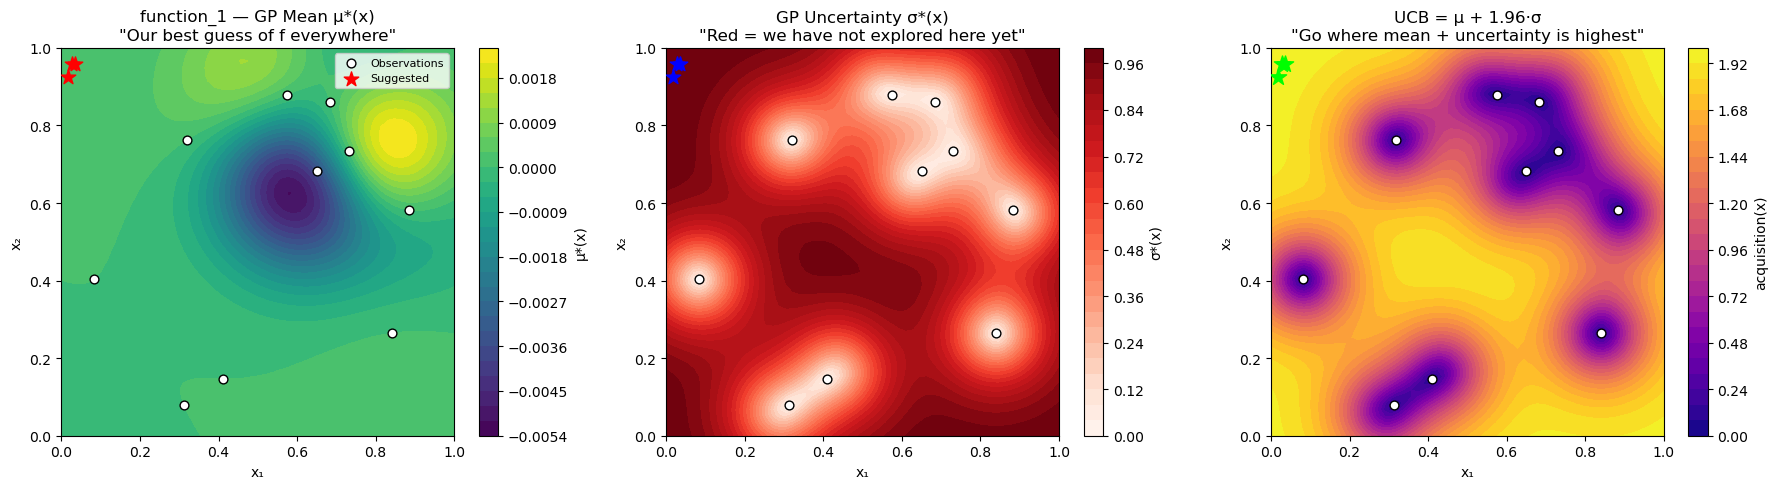

In [6]:
"""
FUNCTION 1 — 2D, contamination sources

Multiple sharp peaks (strong + weak sources).
UCB with β=1.96 balances finding new peaks with improving near known ones.
Length scale 0.15: short → allows the GP to model localised, sharp peaks.
"""

FUNC = 'function_1'
ACQ  = 'UCB'
LS   = 0.15
B    = 1.96

# Merge initial data with any queries you've already logged
X_obs, y_obs = merge_with_initial(FUNC)

print(f"=== {FUNC} ===")
print(f"  Total observations: {len(y_obs)}  (initial + logged queries)")
print(f"  Best y so far:      {max(y_obs):.6f}")
print(f"  Acquisition:        {ACQ}  β={B}  ℓ={LS}")

# Generate suggestion
suggestions, info = suggest_next_query(
    X_obs, y_obs,
    acquisition=ACQ, length_scale=LS, beta=B, n_suggestions=3
)

print(f"\n  Top suggestions:")
for rank, (x_arr, portal_str) in enumerate(suggestions):
    acq_val = (info['mu'][np.argmax(info['acq'])] + B * info['sigma'][np.argmax(info['acq'])])
    print(f"    #{rank+1}  Portal string: {portal_str}")

print(f"\n{'='*60}")
print(f"  ▶▶  SUBMIT THIS TO THE PORTAL:")
print(f"      {suggestions[0][1]}")
print(f"{'='*60}")

# Visualise
visualise_2d(FUNC, X_obs, y_obs, suggestions, info, ACQ)

# ── AFTER SUBMITTING: fill in the y value and run this line ─────────────
# log_query(FUNC, suggestions[0][0], y_value=???, acquisition_used=ACQ)

=== function_2 ===
  Total observations: 10
  Best y so far:      0.611205
  Output std:         0.2254  ← high = multi-modal or noisy

  Top suggestions:
    #1  Portal string: 0.853345-0.298944
    #2  Portal string: 0.853984-0.322216
    #3  Portal string: 0.875539-0.284051

  ▶▶  SUBMIT THIS TO THE PORTAL:
      0.853345-0.298944


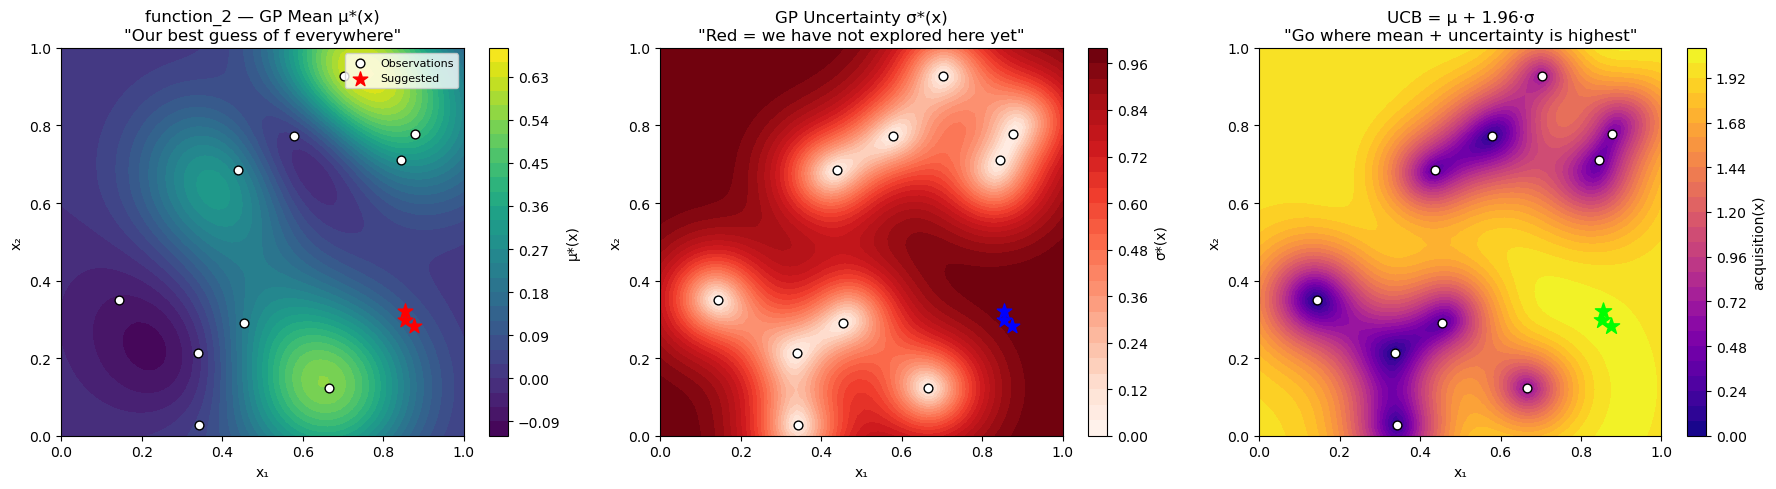

In [7]:
"""
FUNCTION 2 — 2D, noisy mystery ML model

Noisy outputs + complex landscape = easy to get stuck in a local region.
Higher β (2.5) pushes the GP to explore farther from known observations.

THEORY NOTE on noise:
  The problem says outputs are 'noisy'.
  With noise_level=1e-10, the GP fits the data exactly.
  If noise causes repeated nearby queries, increase noise_level to ~0.01
  and the GP will interpolate more smoothly rather than chasing noise.
"""

FUNC = 'function_2'
ACQ  = 'UCB'
LS   = 0.15
B    = 2.5      # higher β → more exploratory

X_obs, y_obs = merge_with_initial(FUNC)

print(f"=== {FUNC} ===")
print(f"  Total observations: {len(y_obs)}")
print(f"  Best y so far:      {max(y_obs):.6f}")
print(f"  Output std:         {np.std(y_obs):.4f}  ← high = multi-modal or noisy")

suggestions, info = suggest_next_query(
    X_obs, y_obs,
    acquisition=ACQ, length_scale=LS, beta=B, n_suggestions=3
)

print(f"\n  Top suggestions:")
for rank, (x_arr, portal_str) in enumerate(suggestions):
    print(f"    #{rank+1}  Portal string: {portal_str}")

print(f"\n{'='*60}")
print(f"  ▶▶  SUBMIT THIS TO THE PORTAL:")
print(f"      {suggestions[0][1]}")
print(f"{'='*60}")

visualise_2d(FUNC, X_obs, y_obs, suggestions, info, ACQ)

# log_query(FUNC, suggestions[0][0], y_value=???, acquisition_used=ACQ)

=== function_3 ===
  Total observations: 15  (15 initial + logged queries)
  Output range:       [-0.3989, -0.0348]
  Best so far:        -0.034835  ← closest to 0 = fewest side effects
  Threshold to beat:  -0.029835  (best + η=0.005)

  Top suggestions (3 compound concentrations each):
    #1  Portal string: 0.278076-0.304705-0.427903
    #2  Portal string: 0.447126-0.552333-0.409502
    #3  Portal string: 0.334094-0.272045-0.460037

  ▶▶  SUBMIT THIS TO THE PORTAL:
      0.278076-0.304705-0.427903


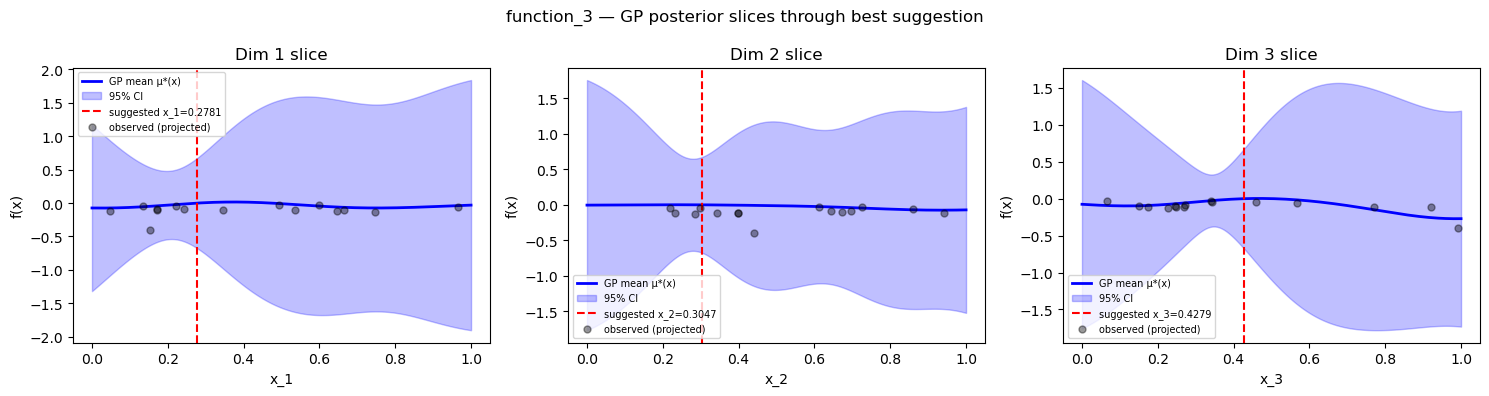

In [8]:
"""
FUNCTION 3 — 3D, drug discovery (minimise side effects → output is negated)

Three compound concentrations. Output = -(side effects).
Best outcome = closest to 0 (fewest side effects).

PI is appropriate here:
  In a medical context, we want a GUARANTEE that the next experiment
  will beat the current best, not just an optimistic bet (UCB).
  η=0.005 = accept small but real improvements.

THEORY: PI z-score for this function
  If μ(x)=−0.10 and y_max=−0.08 and η=0.005:
    z = (−0.10 − (−0.08) − 0.005) / σ = −0.025 / σ  < 0
    PI = Φ(negative) < 0.5  → probably won't improve
  If μ(x)=−0.07 and y_max=−0.08:
    z = (−0.07 − (−0.08) − 0.005) / σ = +0.005 / σ  ≈ 0
    PI = Φ(≈0) ≈ 0.5  → roughly 50% chance of improvement
"""

FUNC = 'function_3'
ACQ  = 'PI'
LS   = 0.2
E    = 0.005

X_obs, y_obs = merge_with_initial(FUNC)

print(f"=== {FUNC} ===")
print(f"  Total observations: {len(y_obs)}  (15 initial + logged queries)")
print(f"  Output range:       [{y_obs.min():.4f}, {y_obs.max():.4f}]")
print(f"  Best so far:        {max(y_obs):.6f}  ← closest to 0 = fewest side effects")
print(f"  Threshold to beat:  {max(y_obs) + E:.6f}  (best + η={E})")

suggestions, info = suggest_next_query(
    X_obs, y_obs,
    acquisition=ACQ, length_scale=LS, eta=E, n_suggestions=3
)

print(f"\n  Top suggestions (3 compound concentrations each):")
for rank, (x_arr, portal_str) in enumerate(suggestions):
    print(f"    #{rank+1}  Portal string: {portal_str}")

print(f"\n{'='*60}")
print(f"  ▶▶  SUBMIT THIS TO THE PORTAL:")
print(f"      {suggestions[0][1]}")
print(f"{'='*60}")

visualise_high_dim(FUNC, X_obs, y_obs, suggestions, info, d=3)

# log_query(FUNC, suggestions[0][0], y_value=???, acquisition_used=ACQ)

=== function_4 ===
  Total observations: 30
  Best so far:        -4.025542
  Per-dimension input ranges:
    x_1: [0.038, 0.986]
    x_2: [0.006, 0.920]
    x_3: [0.042, 0.939]
    x_4: [0.082, 0.999]

  Top suggestions (4 hyperparameters each):
    #1  Portal string: 0.004306-0.571167-0.994078-0.038644
    #2  Portal string: 0.119673-0.364919-0.958429-0.995464
    #3  Portal string: 0.849066-0.225242-0.027664-0.038225

  ▶▶  SUBMIT THIS TO THE PORTAL:
      0.004306-0.571167-0.994078-0.038644


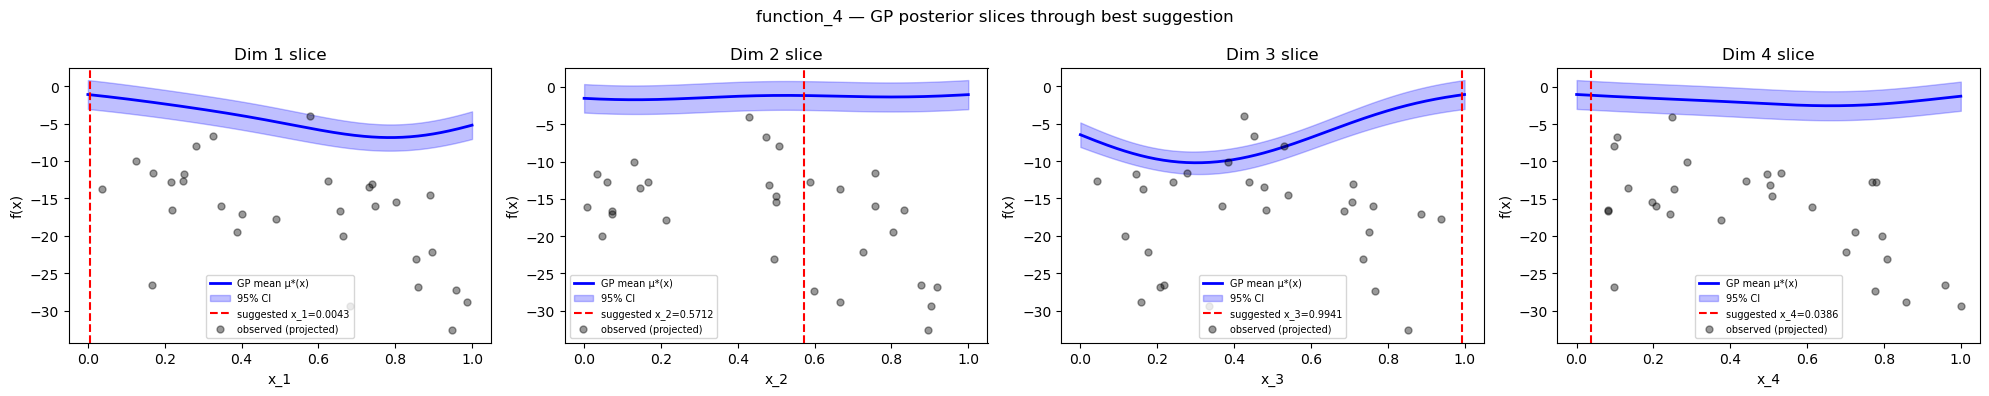

In [9]:
"""
FUNCTION 4 — 4D, warehouse/ML model (many local optima)

Four hyperparameters. 30 initial points in 4D.
Complex landscape with local optima → UCB explores broadly.

Length scale 0.25: slightly longer than default.
  Reason: 30 points in 4D is still sparse. A longer ℓ makes the GP smoother
  and avoids overfitting to noise in the initial data.
  A shorter ℓ would create a 'spiky' surrogate that misses the big picture.
"""

FUNC = 'function_4'
ACQ  = 'UCB'
LS   = 0.25
B    = 2.0

X_obs, y_obs = merge_with_initial(FUNC)

print(f"=== {FUNC} ===")
print(f"  Total observations: {len(y_obs)}")
print(f"  Best so far:        {max(y_obs):.6f}")
print(f"  Per-dimension input ranges:")
for i in range(4):
    print(f"    x_{i+1}: [{X_obs[:,i].min():.3f}, {X_obs[:,i].max():.3f}]")

suggestions, info = suggest_next_query(
    X_obs, y_obs,
    acquisition=ACQ, length_scale=LS, beta=B, n_suggestions=3
)

print(f"\n  Top suggestions (4 hyperparameters each):")
for rank, (x_arr, portal_str) in enumerate(suggestions):
    print(f"    #{rank+1}  Portal string: {portal_str}")

print(f"\n{'='*60}")
print(f"  ▶▶  SUBMIT THIS TO THE PORTAL:")
print(f"      {suggestions[0][1]}")
print(f"{'='*60}")

visualise_high_dim(FUNC, X_obs, y_obs, suggestions, info, d=4)

# log_query(FUNC, suggestions[0][0], y_value=???, acquisition_used=ACQ)

=== function_5 ===
  Total observations: 20
  Best so far:        1088.859618
  Top-5 input spread: 0.205  (spread → may be multi-modal)
  Top-5 observations:
    #1: y=1088.8596  x=[0.224 0.846 0.879 0.879]
    #2: y=431.6128  x=[0.12  0.863 0.643 0.85 ]
    #3: y=355.8068  x=[0.439 0.774 0.378 0.934]
    #4: y=258.3705  x=[0.836 0.194 0.664 0.786]
    #5: y=233.2236  x=[0.463 0.63  0.108 0.958]

  Top suggestions:
    #1  Portal string: 0.135326-0.479135-0.232246-0.952072
    #2  Portal string: 0.800577-0.853651-0.153492-0.582682
    #3  Portal string: 0.288553-0.241314-0.082428-0.496565

  ▶▶  SUBMIT THIS TO THE PORTAL:
      0.135326-0.479135-0.232246-0.952072


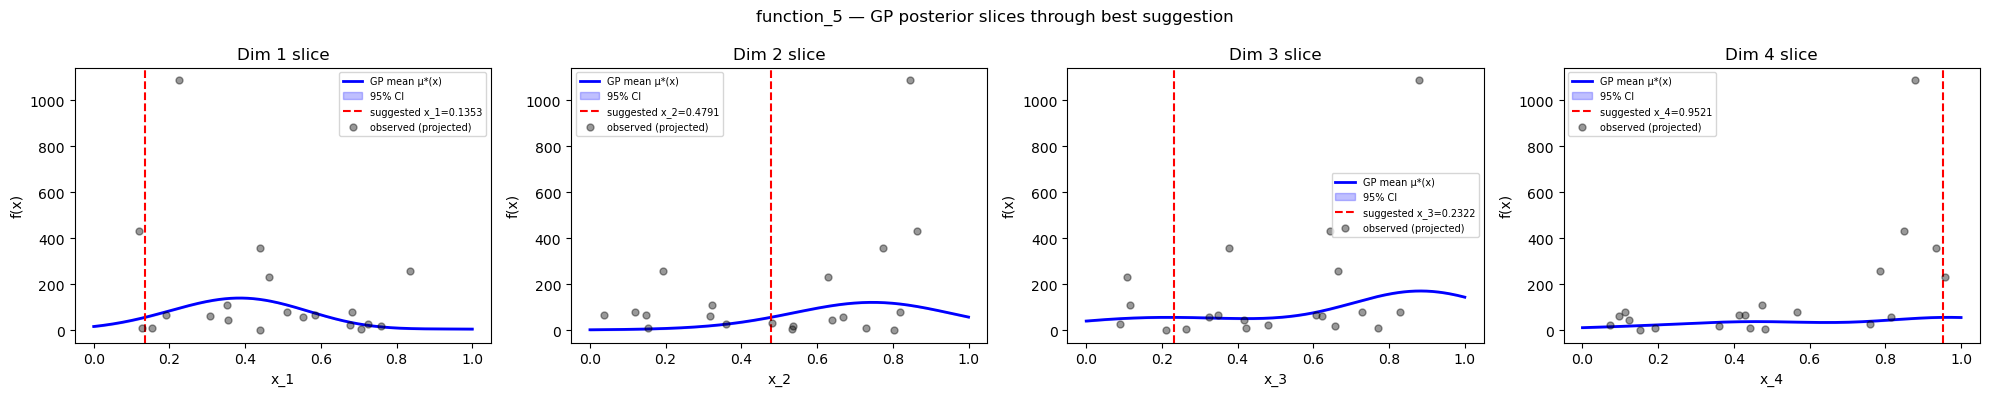

In [10]:
"""
FUNCTION 5 — 4D, chemical yield (likely unimodal)

Four chemical inputs. Output = yield.
The brief says 'typically unimodal with a single peak'.

PI is ideal for unimodal functions:
  Once the GP finds the peak region, PI focuses tightly on it.
  UCB would keep exploring elsewhere unnecessarily.

We test for unimodality below: if the top observations cluster together
(low spread), that's evidence of a single peak → PI is the right choice.
"""

FUNC = 'function_5'
ACQ  = 'PI'
LS   = 0.2
E    = 0.01

X_obs, y_obs = merge_with_initial(FUNC)

# Unimodality check: are the top observations geographically close?
top5_idx = np.argsort(y_obs)[::-1][:5]
top5_X   = X_obs[top5_idx]
spread   = top5_X.std(axis=0).mean()

print(f"=== {FUNC} ===")
print(f"  Total observations: {len(y_obs)}")
print(f"  Best so far:        {max(y_obs):.6f}")
print(f"  Top-5 input spread: {spread:.3f}  ", end='')
print(f"({'clustered → unimodal likely ✓' if spread < 0.2 else 'spread → may be multi-modal'})")
print(f"  Top-5 observations:")
for i, idx in enumerate(top5_idx):
    print(f"    #{i+1}: y={y_obs[idx]:.4f}  x={np.round(X_obs[idx], 3)}")

suggestions, info = suggest_next_query(
    X_obs, y_obs,
    acquisition=ACQ, length_scale=LS, eta=E, n_suggestions=3
)

print(f"\n  Top suggestions:")
for rank, (x_arr, portal_str) in enumerate(suggestions):
    print(f"    #{rank+1}  Portal string: {portal_str}")

print(f"\n{'='*60}")
print(f"  ▶▶  SUBMIT THIS TO THE PORTAL:")
print(f"      {suggestions[0][1]}")
print(f"{'='*60}")

visualise_high_dim(FUNC, X_obs, y_obs, suggestions, info, d=4)

# log_query(FUNC, suggestions[0][0], y_value=???, acquisition_used=ACQ)

=== function_6 ===
  Total observations: 20
  Output range:       [-2.5712, -0.7143]  ← all negative, closer to 0 = better
  Best so far:        -0.714265  ← least negative value

  GP works with negative outputs — no transformation needed.
  UCB will suggest where: μ(x) + β·σ(x) is highest (least negative).

  Top suggestions (5 ingredient amounts each):
    #1  Portal string: 0.021302-0.222963-0.053251-0.898148-0.005297
    #2  Portal string: 0.833459-0.051962-0.924842-0.099113-0.843575
    #3  Portal string: 0.015581-0.206630-0.312388-0.178207-0.020144

  ▶▶  SUBMIT THIS TO THE PORTAL:
      0.021302-0.222963-0.053251-0.898148-0.005297


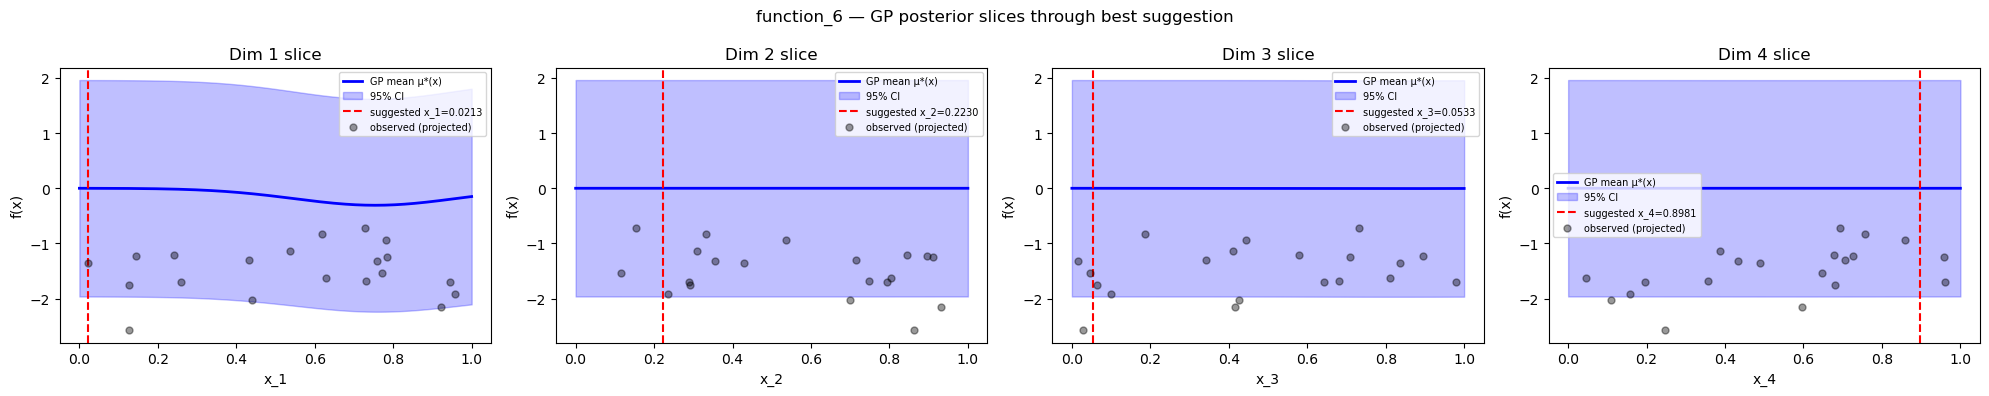

In [11]:
"""
FUNCTION 6 — 5D, cake recipe (combined score, outputs ≤ 0)

Five ingredients: flour, sugar, eggs, butter, milk.
Output = combined negative score (flavour + consistency + calories + waste + cost).
Goal: maximise towards 0 (least negative = best recipe).

IMPORTANT: outputs are negative. The GP handles this naturally.
  UCB will point to the region with the HIGHEST (least negative) upper bound.
  The portal will return a negative number — that is correct.
"""

FUNC = 'function_6'
ACQ  = 'UCB'
LS   = 0.2
B    = 1.96

X_obs, y_obs = merge_with_initial(FUNC)

print(f"=== {FUNC} ===")
print(f"  Total observations: {len(y_obs)}")
print(f"  Output range:       [{y_obs.min():.4f}, {y_obs.max():.4f}]  ← all negative, closer to 0 = better")
print(f"  Best so far:        {max(y_obs):.6f}  ← least negative value")
print(f"\n  GP works with negative outputs — no transformation needed.")
print(f"  UCB will suggest where: μ(x) + β·σ(x) is highest (least negative).")

suggestions, info = suggest_next_query(
    X_obs, y_obs,
    acquisition=ACQ, length_scale=LS, beta=B, n_suggestions=3
)

print(f"\n  Top suggestions (5 ingredient amounts each):")
for rank, (x_arr, portal_str) in enumerate(suggestions):
    print(f"    #{rank+1}  Portal string: {portal_str}")

print(f"\n{'='*60}")
print(f"  ▶▶  SUBMIT THIS TO THE PORTAL:")
print(f"      {suggestions[0][1]}")
print(f"{'='*60}")

visualise_high_dim(FUNC, X_obs, y_obs, suggestions, info, d=5)

# log_query(FUNC, suggestions[0][0], y_value=???, acquisition_used=ACQ)

=== function_7 ===
  Total observations: 30
  Best so far:        1.364968
  Per-dimension input ranges:
    x_1: mean=0.511  std=0.299
    x_2: mean=0.396  std=0.248
    x_3: mean=0.390  std=0.309
    x_4: mean=0.513  std=0.307
    x_5: mean=0.467  std=0.309
    x_6: mean=0.485  std=0.265

  Top suggestions (6 hyperparameters each):
    #1  Portal string: 0.182486-0.168953-0.179255-0.330841-0.280620-0.836425
    #2  Portal string: 0.043607-0.157185-0.240173-0.072519-0.355691-0.675166
    #3  Portal string: 0.059596-0.127184-0.375943-0.322541-0.219679-0.840129

  ▶▶  SUBMIT THIS TO THE PORTAL:
      0.182486-0.168953-0.179255-0.330841-0.280620-0.836425


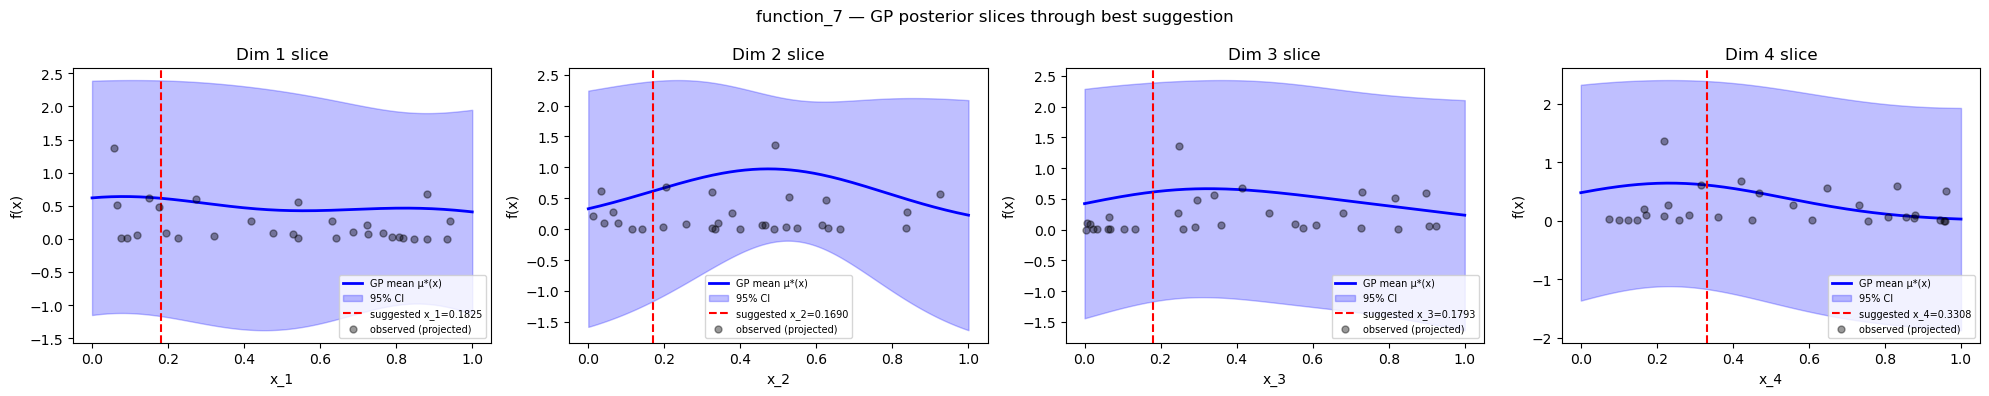

In [12]:
"""
FUNCTION 7 — 6D, ML hyperparameter optimisation

Six hyperparameters (learning rate, regularisation, layers, etc.).
30 points in 6D = very sparse. This is hard for the GP.

High β (2.5) ensures we explore rather than over-commit to a local region.
Longer ℓ (0.3) keeps the surrogate smooth despite sparse data.

More candidates per dimension (700 × 6 = 4200) for better coverage.
"""

FUNC = 'function_7'
ACQ  = 'UCB'
LS   = 0.3
B    = 2.5

X_obs, y_obs = merge_with_initial(FUNC)

print(f"=== {FUNC} ===")
print(f"  Total observations: {len(y_obs)}")
print(f"  Best so far:        {max(y_obs):.6f}")
print(f"  Per-dimension input ranges:")
for i in range(6):
    print(f"    x_{i+1}: mean={X_obs[:,i].mean():.3f}  std={X_obs[:,i].std():.3f}")

suggestions, info = suggest_next_query(
    X_obs, y_obs,
    acquisition=ACQ, length_scale=LS, beta=B,
    candidates_per_dim=700,    # more candidates for 6D coverage
    n_suggestions=3
)

print(f"\n  Top suggestions (6 hyperparameters each):")
for rank, (x_arr, portal_str) in enumerate(suggestions):
    print(f"    #{rank+1}  Portal string: {portal_str}")

print(f"\n{'='*60}")
print(f"  ▶▶  SUBMIT THIS TO THE PORTAL:")
print(f"      {suggestions[0][1]}")
print(f"{'='*60}")

visualise_high_dim(FUNC, X_obs, y_obs, suggestions, info, d=6)

# log_query(FUNC, suggestions[0][0], y_value=???, acquisition_used=ACQ)

=== function_8 ===
  Total observations: 40  (very sparse in 8D!)
  Output range:       [5.5922, 9.5985]  ← should be 0–1
  Best so far:        9.598482

  Why Variance for 8D?
    40 points / 8D space → average distance between points ≈ large
    UCB mean is unreliable far from observations.
    Variance: 'I don't know what's here — let's find out.'

  Top suggestions (8 parameters each):
    #1  Portal string: 0.824416-0.925687-0.201348-0.929573-0.017861-0.924962-0.951929-0.012052
    #2  Portal string: 0.087440-0.994495-0.037786-0.919516-0.080198-0.859298-0.548242-0.196335
    #3  Portal string: 0.024385-0.924633-0.015320-0.911524-0.031793-0.410291-0.782943-0.024778

  ▶▶  SUBMIT THIS TO THE PORTAL:
      0.824416-0.925687-0.201348-0.929573-0.017861-0.924962-0.951929-0.012052


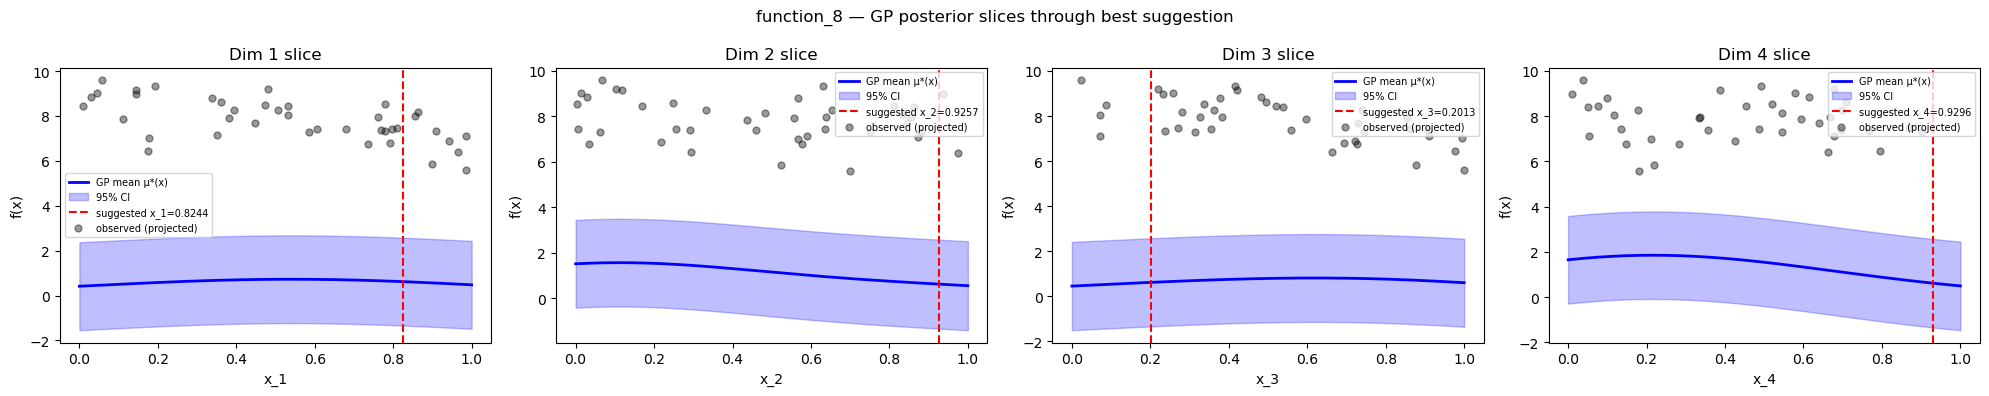

In [13]:
"""
FUNCTION 8 — 8D, 8 deep learning hyperparameters (output: validation accuracy 0–1)

Eight inputs: learning rate, batch size, layers, dropout, regularisation,
             activation (encoded), optimiser (encoded), weight range.
Output: validation accuracy in [0, 1].

This is the hardest function.
  40 points in [0,1]^8 = negligible coverage of a huge space.

Variance (pure exploration) is the right choice:
  THEORY: With 40 points in 8D, most of the space has σ ≈ 1 (prior uncertainty).
  The GP mean μ is unreliable far from observations.
  UCB's mean term would mislead — we might greedily exploit a bad local region.
  Variance says: 'go where I know nothing' — at least we gather real information.

Longer ℓ (0.4): prevents the GP from creating too many wiggles in 8D.
More candidates (1000 × 8 = 8000): ensures better coverage of the 8D space.
"""

FUNC = 'function_8'
ACQ  = 'Variance'
LS   = 0.4

X_obs, y_obs = merge_with_initial(FUNC)

print(f"=== {FUNC} ===")
print(f"  Total observations: {len(y_obs)}  (very sparse in 8D!)")
print(f"  Output range:       [{y_obs.min():.4f}, {y_obs.max():.4f}]  ← should be 0–1")
print(f"  Best so far:        {max(y_obs):.6f}")
print(f"\n  Why Variance for 8D?")
print(f"    40 points / 8D space → average distance between points ≈ large")
print(f"    UCB mean is unreliable far from observations.")
print(f"    Variance: 'I don't know what's here — let's find out.'")

suggestions, info = suggest_next_query(
    X_obs, y_obs,
    acquisition=ACQ, length_scale=LS,
    candidates_per_dim=1000,   # 8000 total candidates for 8D
    n_suggestions=3
)

print(f"\n  Top suggestions (8 parameters each):")
for rank, (x_arr, portal_str) in enumerate(suggestions):
    print(f"    #{rank+1}  Portal string: {portal_str}")

print(f"\n{'='*60}")
print(f"  ▶▶  SUBMIT THIS TO THE PORTAL:")
print(f"      {suggestions[0][1]}")
print(f"{'='*60}")

visualise_high_dim(FUNC, X_obs, y_obs, suggestions, info, d=8)

# log_query(FUNC, suggestions[0][0], y_value=???, acquisition_used=ACQ)

---

## Step 6 — Summary and Submission Checklist

In [14]:
"""
STEP 6 — Print a clean summary of current best values and suggestions.
Run this after logging results to see the full picture.
"""

acq_settings = {
    'function_1': ('UCB',      'β=1.96, ℓ=0.15'),
    'function_2': ('UCB',      'β=2.5,  ℓ=0.15'),
    'function_3': ('PI',       'η=0.005, ℓ=0.2'),
    'function_4': ('UCB',      'β=2.0,  ℓ=0.25'),
    'function_5': ('PI',       'η=0.01,  ℓ=0.2'),
    'function_6': ('UCB',      'β=1.96, ℓ=0.2'),
    'function_7': ('UCB',      'β=2.5,  ℓ=0.3'),
    'function_8': ('Variance', 'ℓ=0.4'),
}

print("=" * 80)
print(" STATUS — All 8 Functions")
print("=" * 80)
print(f"  {'Function':<14} {'Dim':<5} {'Obs':<6} {'Best y':<14} {'Acquisition':<12} {'Settings'}")
print(f"  {'-'*78}")

for fname, (acq, settings) in acq_settings.items():
    X_all, y_all = merge_with_initial(fname)
    d    = data[fname]['input'].shape[1]
    print(f"  {fname:<14} {d:<5} {len(y_all):<6} {max(y_all):<14.6f} {acq:<12} {settings}")

print(f"\n{'='*80}")
print(" PORTAL SUBMISSION WORKFLOW")
print("="*80)
print("""
  For each function, each module:

  1. Re-run that function's cell above
     (it automatically uses all logged observations)

  2. Copy the string after '▶▶ SUBMIT THIS TO THE PORTAL:'
     Example: 0.312456-0.728931

  3. Paste into the capstone portal → submit → note the y value

  4. Uncomment the log_query line and fill in the y value:
     log_query('function_1', suggestions[0][0], y_value=1.234567, acquisition_used='UCB')

  5. The log file keeps a complete record:
     timestamp | function | x_portal | y_value | acquisition

  6. Next time you run the cell, the new observation is automatically
     included → the GP improves → better suggestions.

FORMAT REMINDER:
  Portal format: x1-x2-x3-...-xn
  Each xi: 6 decimal places, starts with 0 (domain is [0, 1])
  Example 2D: 0.312456-0.728931
  Example 8D: 0.123456-0.234567-0.345678-0.456789-0.567890-0.678901-0.789012-0.890123
""")

 STATUS — All 8 Functions
  Function       Dim   Obs    Best y         Acquisition  Settings
  ------------------------------------------------------------------------------
  function_1     2     10     0.000000       UCB          β=1.96, ℓ=0.15
  function_2     2     10     0.611205       UCB          β=2.5,  ℓ=0.15
  function_3     3     15     -0.034835      PI           η=0.005, ℓ=0.2
  function_4     4     30     -4.025542      UCB          β=2.0,  ℓ=0.25
  function_5     4     20     1088.859618    PI           η=0.01,  ℓ=0.2
  function_6     5     20     -0.714265      UCB          β=1.96, ℓ=0.2
  function_7     6     30     1.364968       UCB          β=2.5,  ℓ=0.3
  function_8     8     40     9.598482       Variance     ℓ=0.4

 PORTAL SUBMISSION WORKFLOW

  For each function, each module:

  1. Re-run that function's cell above
     (it automatically uses all logged observations)

  2. Copy the string after '▶▶ SUBMIT THIS TO THE PORTAL:'
     Example: 0.312456-0.728931

  3

---

## Quick Reference: Theory ↔ Code

| Concept | Formula | Python line |
|---------|---------|-------------|
| RBF kernel | $k(x,x') = \exp(-\|x-x'\|^2/2\ell^2)$ | `RBF(length_scale=ℓ)` |
| Fit GP | $[k(X,X)+\sigma^2I]^{-1}y$ | `gp.fit(X_obs, y_obs)` |
| Posterior mean | $\mu^*(x)$ | `mu, _ = gp.predict(X_cand, return_std=True)` |
| Posterior std | $\sigma^*(x)$ | `_, sigma = gp.predict(X_cand, return_std=True)` |
| UCB | $\mu + \beta\sigma$ | `acq = mu + beta * sigma` |
| Variance | $\sigma^2$ | `acq = sigma ** 2` |
| PI z-score | $(\mu - y^*_{\max} - \eta)/\sigma$ | `z = (mu - y_max - eta) / (sigma + 1e-12)` |
| PI | $\Phi(z)$ | `acq = norm.cdf(z)` |
| Best candidate | $\arg\max_x \text{acq}(x)$ | `X_cand[np.argmax(acq)]` |
| Portal format | `x1-x2-...-xn` (6 d.p.) | `"-".join([f"{xi:.6f}" for xi in x])` |